# V1 — Classificador Posicional (33 Features)

Pipeline completo para a versão V1 do classificador de qualidade de lances de xadrez.
Features exclusivamente posicionais: material, mobilidade, segurança do rei, estrutura de peões, controle do centro, características do lance, contexto.

---

## 1. Setup

In [1]:
import json
import os
import random
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*", category=UserWarning)
plt.rcParams.update({"font.size": 11, "figure.facecolor": "white"})
sns.set_style("whitegrid")

PROJECT_ROOT = Path("..").resolve()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = Path("data")

from version_config import V1
from notebook_utils import *

config = V1

print(f"Versão: {config.label}")
print(f"Diretório de trabalho: {os.getcwd()}")
print("Setup OK")

Versão: V1 — posicional (33 features)
Diretório de trabalho: /Users/noel/Faculdade/ML/Chess
Setup OK


In [2]:
RERUN_PIPELINE = False
print(f"RERUN_PIPELINE = {RERUN_PIPELINE}")
if RERUN_PIPELINE:
    print("⚠️  O pipeline completo será re-executado.")
else:
    print("Usando dados pré-computados.")

RERUN_PIPELINE = False
Usando dados pré-computados.


---

## 2. Coleta e Descrição dos Dados

### Fonte

Os dados vêm da **Lichess open database** ([database.lichess.org](https://database.lichess.org)), sob licença **CC0** (domínio público).

- **Ficheiro:** `lichess_db_standard_rated_2015-01.pgn.zst` (~272 MiB comprimido)
- **Formato:** PGN comprimido com Zstandard, processado em streaming (memória constante)

### Filtros aplicados

| Filtro | Critério | Justificativa |
|--------|----------|---------------|
| Rating | Ambos 1400–1700 (Lichess) | Faixa-alvo equivalente a 1200–1500 Chess.com |
| Tempo | Blitz/Rapid (3–10 min) | Jogos sérios mas com pressão temporal |
| Término | Normal (mate/resignação) | Evitar jogos decididos por timeout |
| Variante | Standard | Sem Chess960 etc. |
| Fase | Lances 8 a 40 | Meio-jogo (exclui abertura teórica e finais simplificados) |
| Amostragem | 10% das partidas válidas | Controle de volume, seed=42 |

In [3]:
if RERUN_PIPELINE:
    from download_pgn import download

    PGN_URL = "https://database.lichess.org/standard/lichess_db_standard_rated_2015-01.pgn.zst"
    PGN_PATH = DATA_DIR / "raw" / "lichess_db_standard_rated_2015-01.pgn.zst"

    if not PGN_PATH.exists():
        print("Baixando PGN do Lichess (~272 MiB)...")
        download(PGN_URL, PGN_PATH)
    else:
        print(f"PGN já existe: {PGN_PATH}")
else:
    print("⏭️  Download do PGN pulado (usando dados pré-computados).")

⏭️  Download do PGN pulado (usando dados pré-computados).


In [4]:
if RERUN_PIPELINE:
    from filter_games import filter_and_sample, print_stats

    print("Filtrando e amostrando partidas...")
    stats = filter_and_sample(
        pgn_path=DATA_DIR / "raw" / "lichess_db_standard_rated_2015-01.pgn.zst",
        output_path=DATA_DIR / "filtered" / "moves_filtered.csv",
        sample_rate=0.10,
        seed=42,
        max_games=3000,
    )
    print_stats(stats)
else:
    print("⏭️  Filtragem pulada (usando CSV pré-computado).")

⏭️  Filtragem pulada (usando CSV pré-computado).


In [5]:
df_filtered = pd.read_csv(DATA_DIR / "filtered" / "moves_filtered.csv")
print_dataset_stats(df_filtered)
print()
df_filtered.head()

  DATASET FILTRADO
  Partidas       : 2,911
  Lances (total) : 136,620
  Lances/partida : 46.9
  Colunas        : ['game_id', 'game_site', 'white_elo', 'black_elo', 'time_control', 'result', 'move_number', 'color', 'fen_before', 'move_uci', 'move_san']



,game_id,game_site,white_elo,black_elo,time_control,result,move_number,color,fen_before,move_uci,move_san
0,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,8,white,r2qk1nr/pbpp1pbp/1p4p1/3Pp3/1n2P3/2NBBN2/PPP2P...,d3e2,Be2
1,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,8,black,r2qk1nr/pbpp1pbp/1p4p1/3Pp3/1n2P3/2N1BN2/PPP1B...,g8e7,Ne7
2,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,9,white,r2qk2r/pbppnpbp/1p4p1/3Pp3/1n2P3/2N1BN2/PPP1BP...,a2a3,a3
3,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,9,black,r2qk2r/pbppnpbp/1p4p1/3Pp3/1n2P3/P1N1BN2/1PP1B...,b4a6,Na6
4,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,10,white,r2qk2r/pbppnpbp/np4p1/3Pp3/4P3/P1N1BN2/1PP1BPP...,d1d2,Qd2


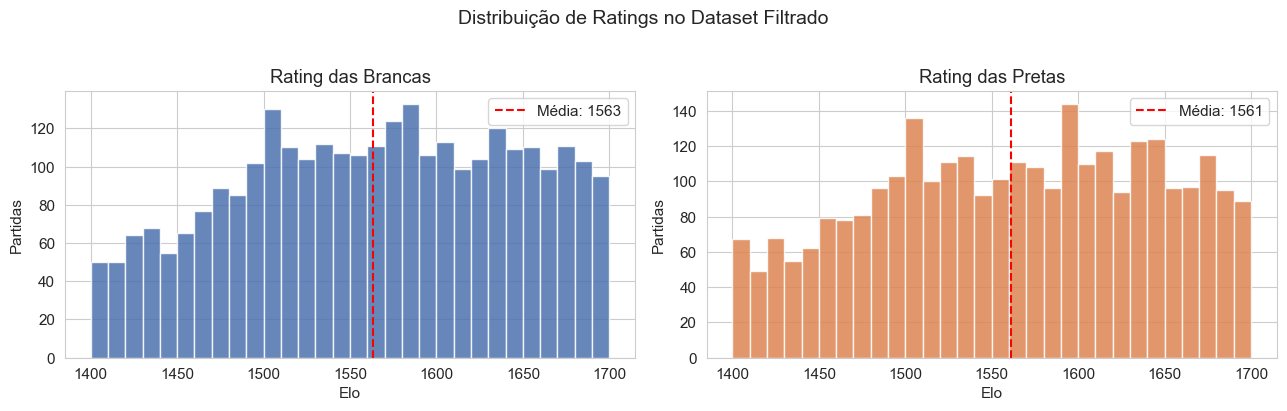

In [6]:
plot_rating_distribution(df_filtered)

---

## 3. Rotulagem via Stockfish

Para cada lance, a qualidade é medida pela **variação da avaliação**:

$$\delta = \text{eval\_depois} - \text{eval\_antes}$$

| Classe | Condição | Significado |
|--------|----------|-------------|
| **Bom** | δ ≥ −50 cp | Perda ≤ 0.5 peão |
| **Descartado** | −150 < δ < −50 | Zona cinzenta |
| **Ruim** | δ ≤ −150 cp | Perda ≥ 1.5 peão |

In [7]:
if RERUN_PIPELINE:
    from label_moves import run as label_run
    print("Rotulando lances com Stockfish (depth 15, 6 workers)...")
    label_run(num_workers=6)
else:
    print("⏭️  Rotulagem pulada (usando CSVs pré-computados).")

⏭️  Rotulagem pulada (usando CSVs pré-computados).


In [8]:
df_scored = pd.read_csv(DATA_DIR / "labeled" / "moves_all_scored.csv")
df_labeled = pd.read_csv(DATA_DIR / "labeled" / "moves_labeled.csv")
print_labeling_stats(df_scored, df_labeled)

  ROTULAGEM
  Lances avaliados      : 136,620
  Bom (δ ≥ −50 cp)      : 92,197 (67.5%)
  Descartado (cinzenta) : 27,330 (20.0%)
  Ruim (δ ≤ −150 cp)    : 17,093 (12.5%)
  ──────────────────────
  Dataset final         : 109,290 (bom + ruim)
  Ratio bom:ruim        : 5.39:1


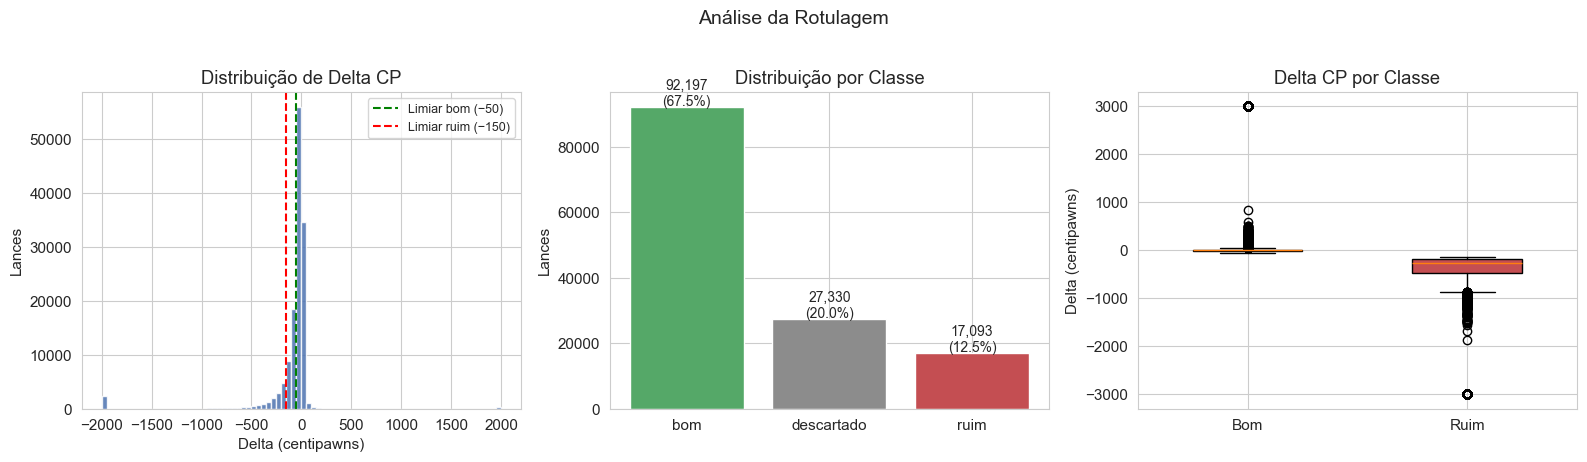

In [9]:
plot_labeling_analysis(df_scored, df_labeled)

---

## 4. Engenharia de Features — V1 (33 Posicionais)

| Grupo | Qtd. | Features |
|-------|------|----------|
| **Material** | 11 | Contagem por tipo/cor + diferença ponderada |
| **Mobilidade** | 3 | Lances legais (jogador/adversário/diferença) |
| **Segurança do rei** | 4 | Roque, direito a roque, escudo de peões |
| **Estrutura de peões** | 4 | Dobrados, isolados, passados |
| **Controle do centro** | 3 | Ataques e ocupação de d4/d5/e4/e5 |
| **Características do lance** | 6 | Captura, xeque, promoção, peça, destino |
| **Contexto** | 2 | Número do lance, cor |

In [10]:
if RERUN_PIPELINE:
    from extract_features import run as extract_run
    print(f"Extraindo {config.n_features} features V{config.version}...")
    extract_run(num_workers=6, batch_size=1000, v2=False, v3=False)
else:
    print(f"⏭️  Extração de features pulada.")
    print(f"   → {config.features_csv}")

⏭️  Extração de features pulada.
   → data/features/features.csv


In [11]:
df_features = pd.read_csv(config.features_csv)
feature_cols = [c for c in df_features.columns if c != "label"]
print_features_stats(df_features, config)
print(f"\nEstatísticas descritivas:")
df_features[feature_cols].describe().round(2)

  FEATURES — V1
  Fonte       : data/features/features.csv
  Linhas      : 109,290
  Features    : 33
  Valores nulos: 0

Distribuição do label:
label
bom     92197
ruim    17093

Estatísticas descritivas:


,white_pawns,white_knights,white_bishops,white_rooks,white_queens,black_pawns,black_knights,black_bishops,black_rooks,black_queens,...,opponent_center_control,player_center_occupation,is_capture,is_check,is_promotion,moved_piece,move_to_center,move_to_extended_center,move_number,is_white
count,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,...,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.0
mean,5.99,0.98,1.05,1.67,0.70,6.00,0.97,1.08,1.66,0.70,...,2.79,0.77,0.30,0.09,0.00,3.22,0.13,0.40,21.22,0.5
std,1.44,0.77,0.77,0.59,0.46,1.44,0.78,0.76,0.60,0.46,...,0.96,0.69,0.46,0.28,0.03,1.70,0.33,0.49,8.89,0.5
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,8.00,0.0
25%,5.00,0.00,0.00,1.00,0.00,5.00,0.00,0.00,1.00,0.00,...,2.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,14.00,0.0
50%,6.00,1.00,1.00,2.00,1.00,6.00,1.00,1.00,2.00,1.00,...,3.00,1.00,0.00,0.00,0.00,3.00,0.00,0.00,20.00,1.0
75%,7.00,2.00,2.00,2.00,1.00,7.00,2.00,2.00,2.00,1.00,...,4.00,1.00,1.00,0.00,0.00,5.00,0.00,1.00,28.00,1.0
max,8.00,2.00,2.00,2.00,2.00,8.00,3.00,2.00,3.00,2.00,...,4.00,4.00,1.00,1.00,1.00,6.00,1.00,1.00,40.00,1.0


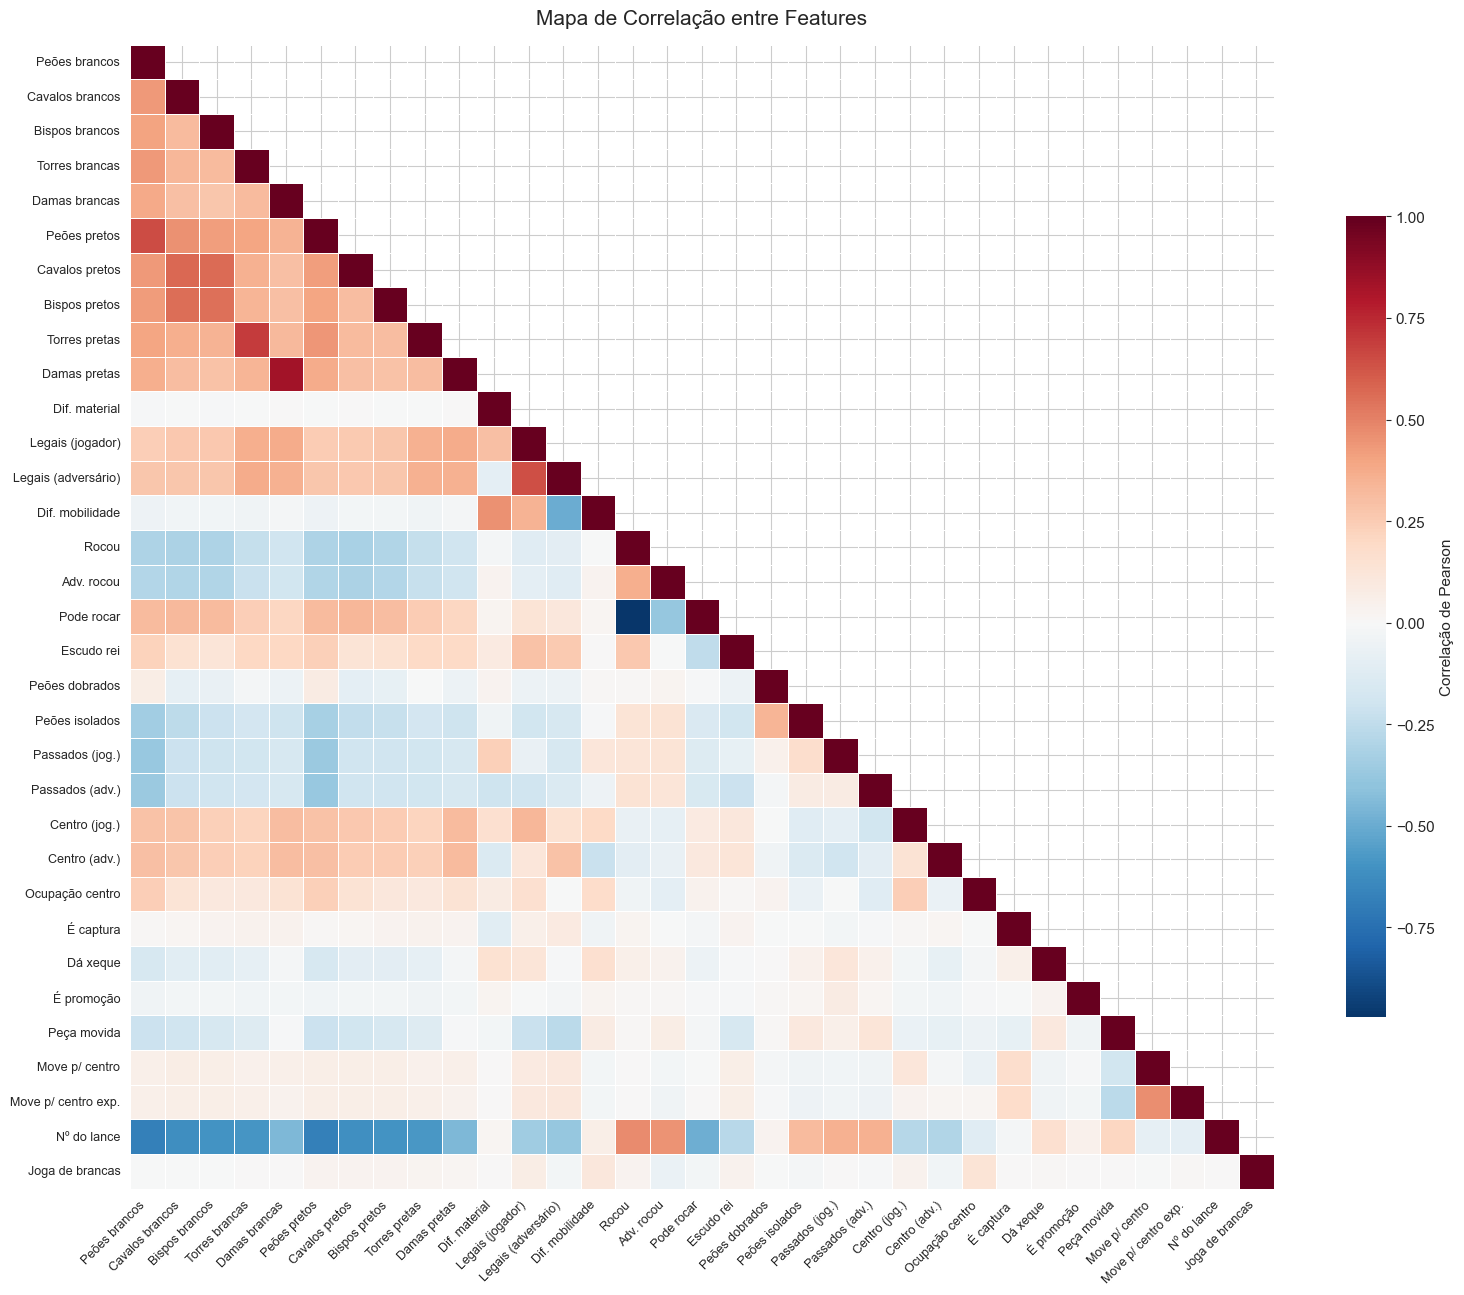

Pares com |correlação| > 0.7:
  Rocou                      ↔  Pode rocar                 r = -0.970
  Damas brancas              ↔  Damas pretas               r = +0.836


In [12]:
plot_correlation_matrix(df_features, feature_cols)

---

## 5. Treino dos Modelos

- Split **70/15/15** (treino/validação/teste) com estratificação
- `class_weight="balanced"` para mitigar desbalanceamento (~5.4:1)
- `GridSearchCV` com 5 folds, métrica F1 da classe "ruim"

In [13]:
X = df_features.drop(columns=["label"])
y = (df_features["label"] == "ruim").astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_SEED
)

print_split_info(X_train, y_train, X_val, y_val, X_test, y_test)

  SPLIT DOS DADOS
  Treino    : 76,546 amostras  (bom=64,574, ruim=11,972, 15.6% ruim)
  Validação : 16,350 amostras  (bom=13,793, ruim=2,557, 15.6% ruim)
  Teste     : 16,394 amostras  (bom=13,830, ruim=2,564, 15.6% ruim)


In [14]:
if RERUN_PIPELINE:
    from train_models import run as train_run
    print(f"Treinando modelos V{config.version}...")
    train_run(v2=config.v2_flag, v3=config.v3_flag)
else:
    print(f"⏭️  Treino pulado (usando modelos pré-treinados de {config.models_dir}).")

dt, rf, feature_names = config.load_models()
print_model_params(dt, rf, config)

⏭️  Treino pulado (usando modelos pré-treinados de data/models).

  DECISION TREE V1 — Melhores hiperparâmetros
  criterion        : gini
  max_depth        : 7
  min_samples_leaf : 20
  class_weight     : balanced

  RANDOM FOREST V1 — Melhores hiperparâmetros
  n_estimators     : 200
  max_depth        : 10
  min_samples_leaf : 5
  class_weight     : balanced


---

## 6. Avaliação

Avaliação no **conjunto de teste** — nunca usado no treino nem no tuning.

In [15]:
print_classification_reports(dt, rf, X_test, y_test)

  DECISION TREE — Classification Report
              precision    recall  f1-score   support

         bom       0.89      0.62      0.73     13830
        ruim       0.23      0.60      0.33      2564

    accuracy                           0.62     16394
   macro avg       0.56      0.61      0.53     16394
weighted avg       0.79      0.62      0.67     16394

  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

         bom       0.89      0.71      0.79     13830
        ruim       0.26      0.55      0.35      2564

    accuracy                           0.68     16394
   macro avg       0.58      0.63      0.57     16394
weighted avg       0.80      0.68      0.72     16394



In [16]:
df_results = build_results_table(dt, rf, X_test, y_test)
print("Tabela comparativa — Conjunto de teste:\n")
df_results

Tabela comparativa — Conjunto de teste:



,Modelo,Accuracy,F1 (bom),F1 (ruim),Recall (ruim),Precision (ruim),ROC-AUC
0,Decision Tree,0.6176,0.7328,0.3280,0.5967,0.2262,0.6487
1,Random Forest,0.6827,0.7899,0.3525,0.5523,0.2589,0.6837


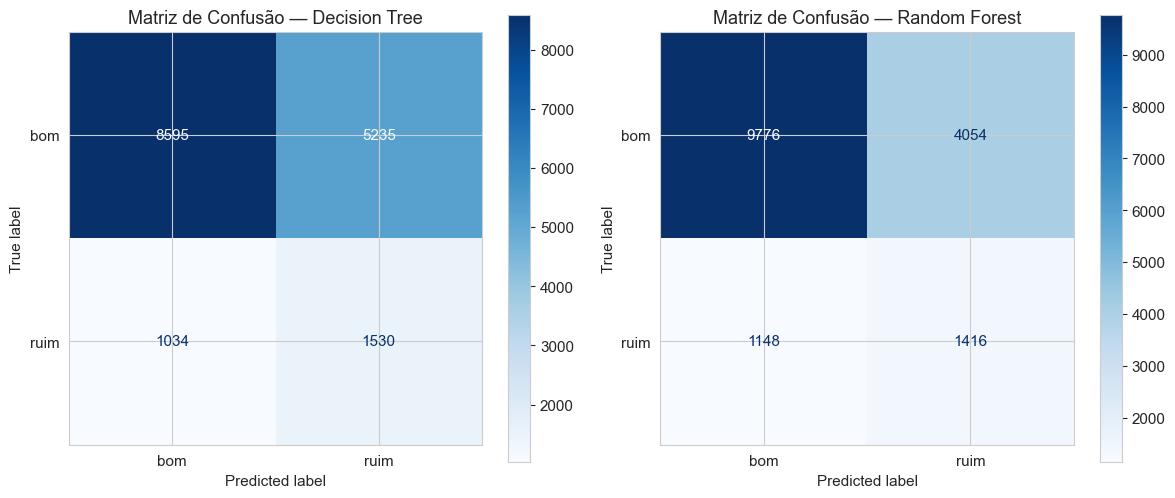

In [17]:
plot_confusion_matrices(dt, rf, X_test, y_test)

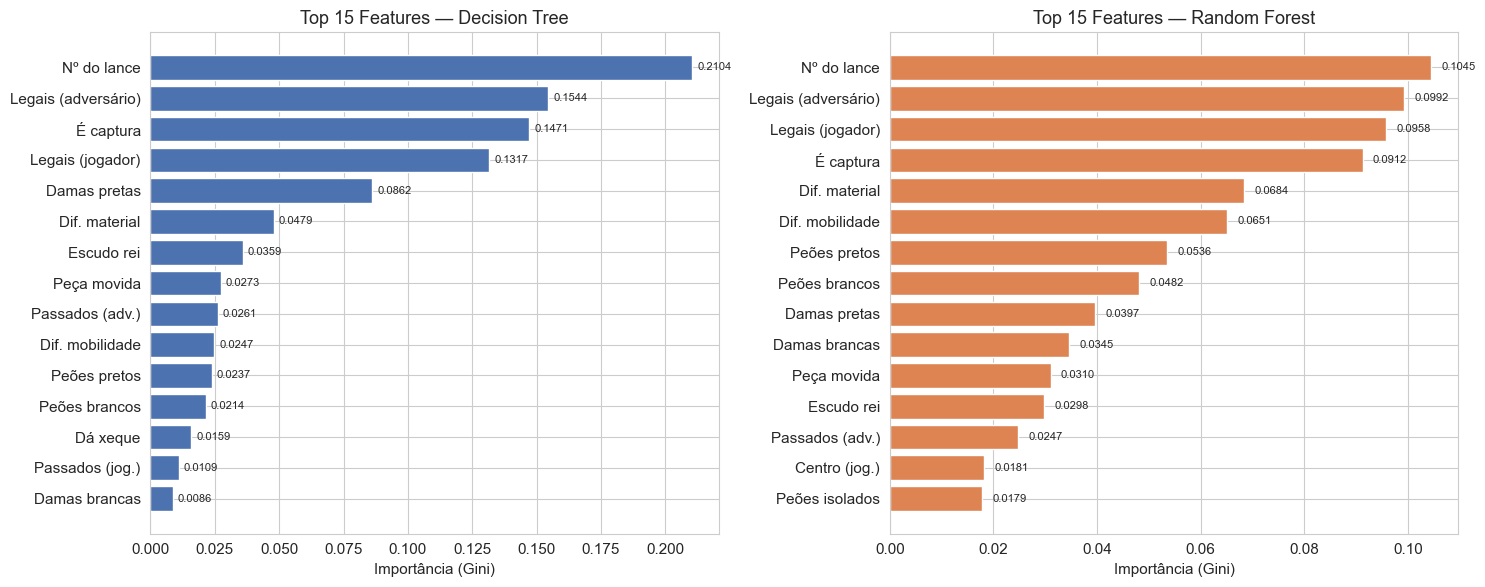

In [18]:
plot_feature_importances_side_by_side(dt, rf, feature_names)

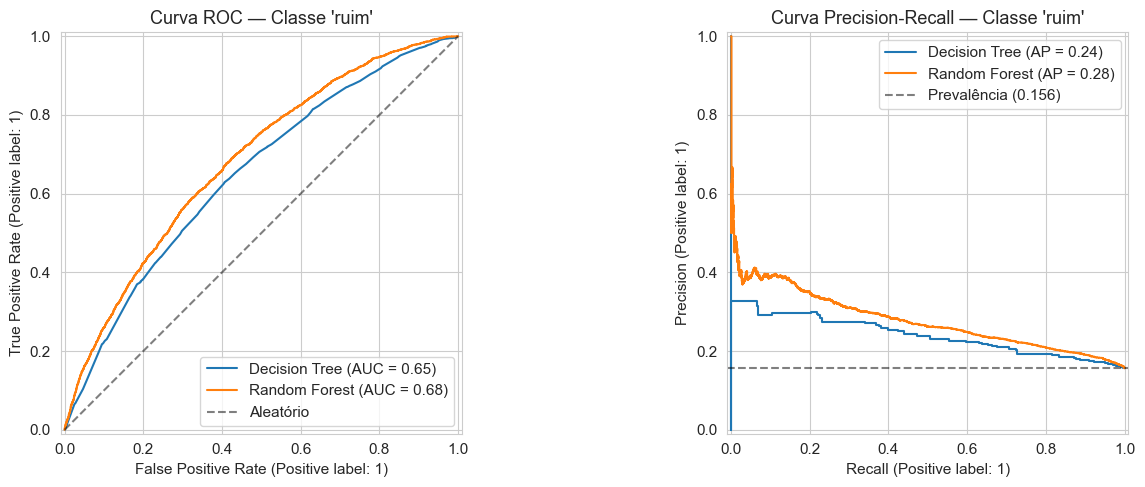

In [19]:
plot_roc_pr_curves(dt, rf, X_test, y_test)

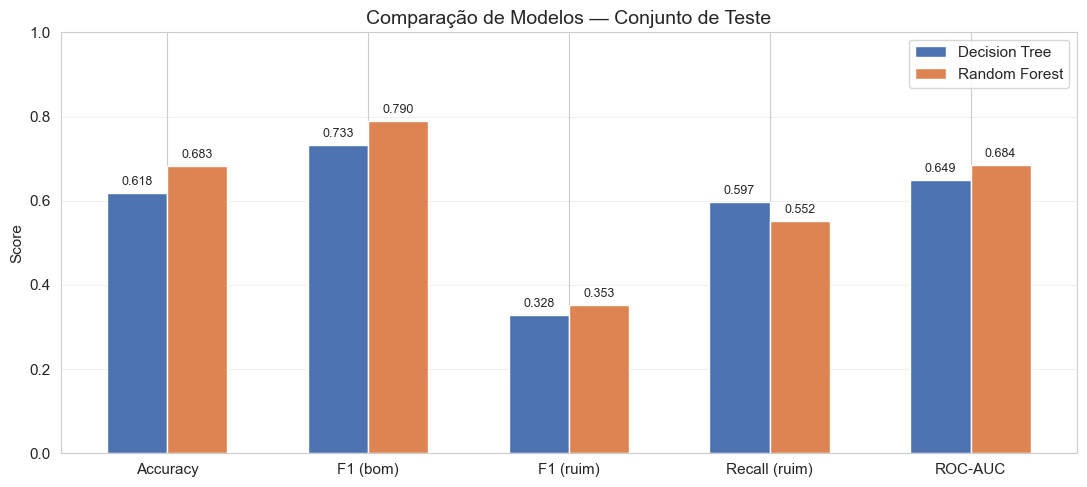

In [20]:
plot_metrics_comparison(dt, rf, X_test, y_test)

/Users/noel/Faculdade/ML/Chess/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/noel/Faculdade/ML/Chess/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/noel/Faculdade/ML/Chess/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/noel/Faculdade/ML/Chess/

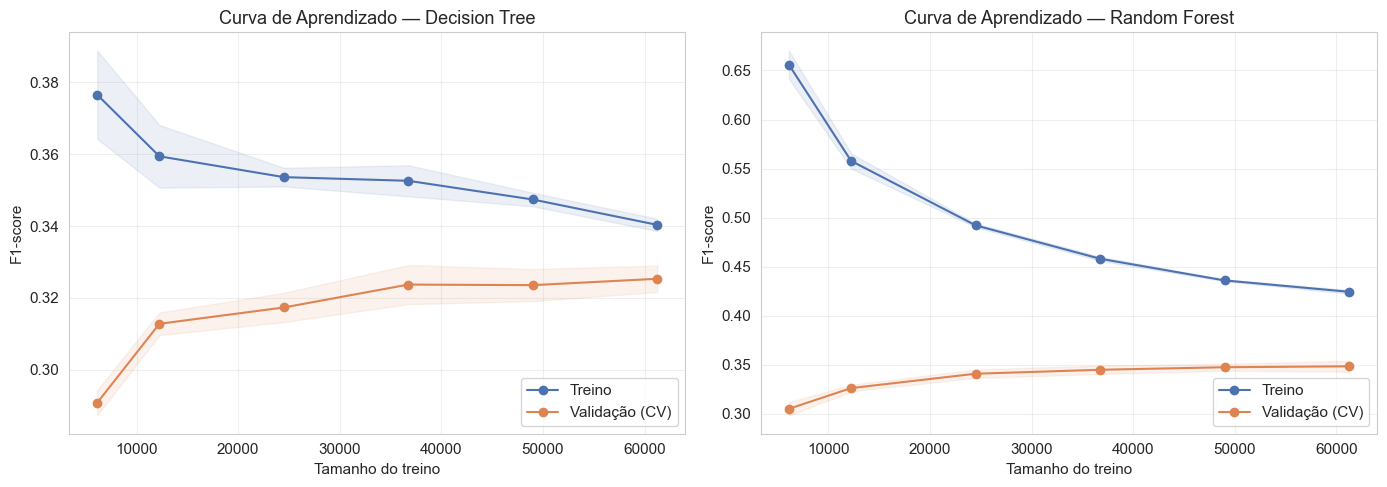

In [21]:
plot_learning_curves(dt, rf, X_train, y_train)

---

## 7. Diagnóstico V1: Por que o F1-ruim é baixo?

### Causa raiz: features não separam as classes

As features posicionais descrevem o **ambiente** (material, mobilidade, segurança do rei), mas os erros de jogadores 1400–1700 são causados por **ameaças táticas concretas**: peças indefesas, cravadas, garfos — nenhuma capturada pelas 33 features V1.

| Hipótese | Evidência contra |
|----------|------------------|
| "Precisamos de mais dados" | Learning curves estáveis — validação plana |
| "O modelo é fraco" | RF e DT concordam; o sinal não existe nas features |
| "O desbalanceamento não foi tratado" | `class_weight="balanced"` já ativo |

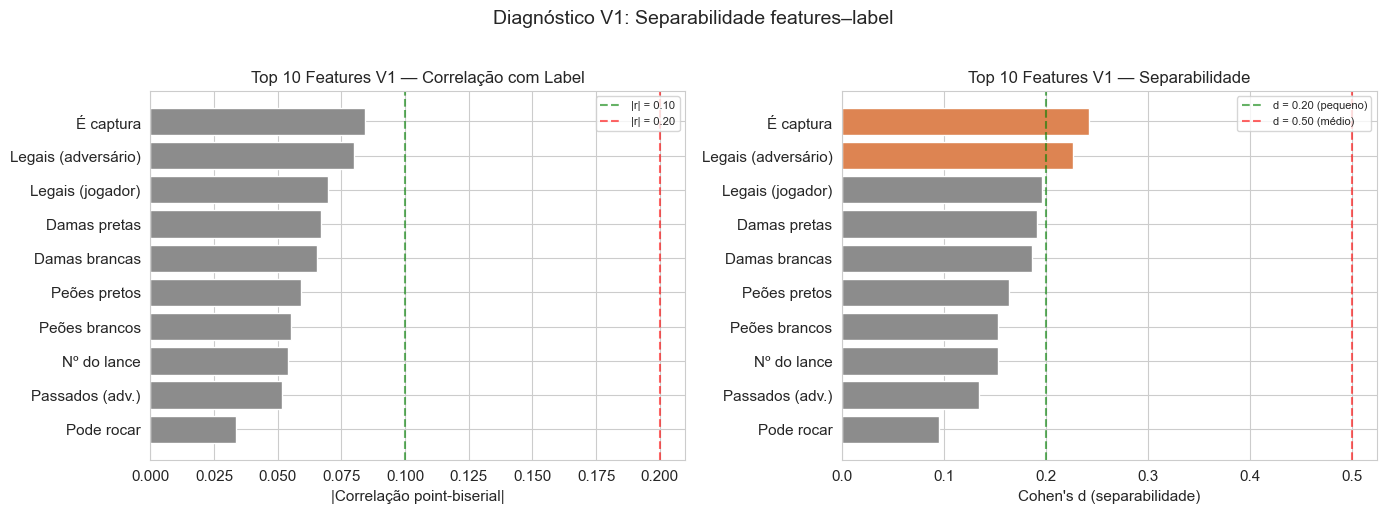

Melhor feature: is_capture → |r| = 0.084, Cohen's d = 0.243
Features com |r| ≥ 0.10: 0


In [22]:
plot_diagnostic(df_features, feature_cols, "V1")

---

## 8. Interpretação

### Regras da Árvore de Decisão

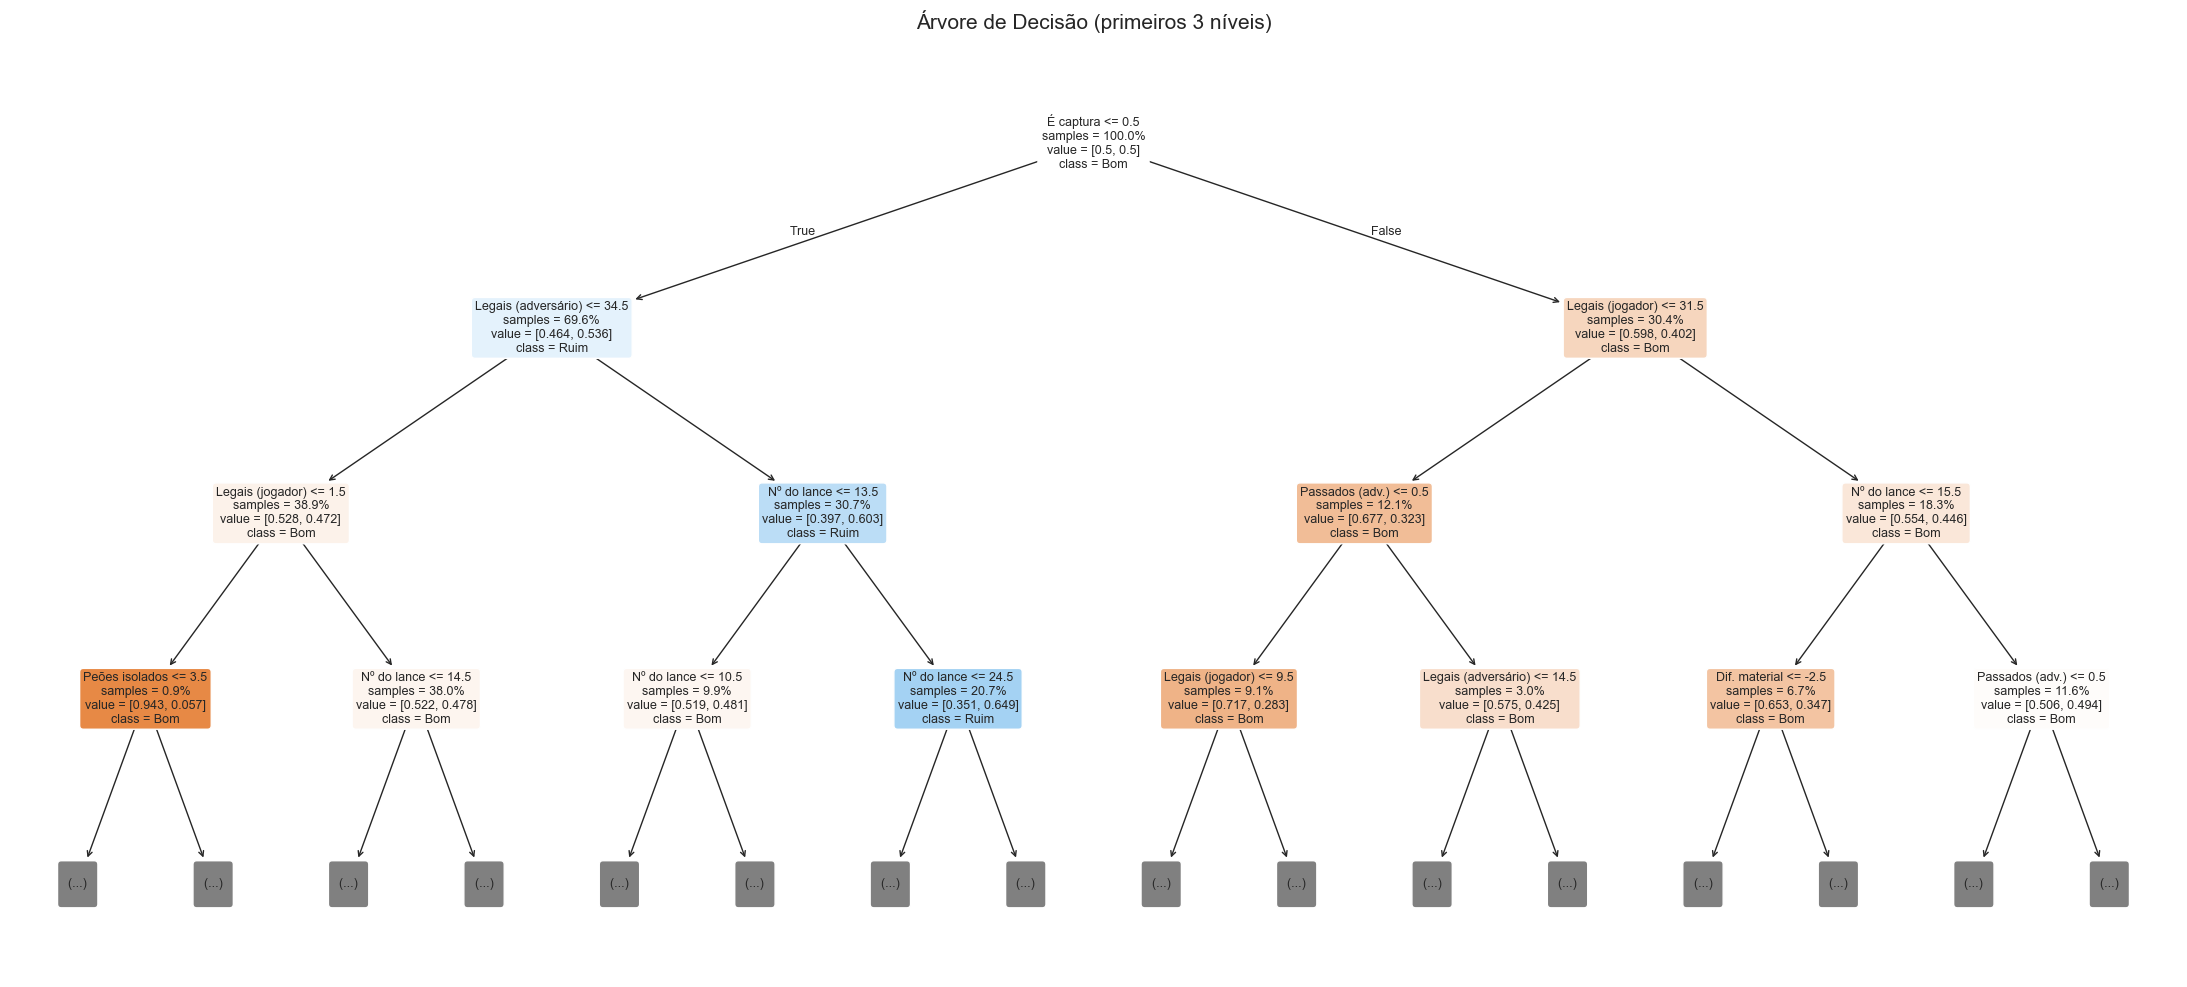

In [23]:
plot_decision_tree(dt, feature_names)

In [24]:
print_tree_rules(config)

═══════════════════════════════════════════════════════════
Regras da Árvore de Decisão — Traduzidas para xadrez
═══════════════════════════════════════════════════════════

Legenda:
  - "Diferença material <= -3.0": jogador com ≥3 pontos a menos
  - "Lances legais (jogador)": mobilidade/atividade das peças
  - "É captura": o lance captura uma peça adversária
  - "Número do lance": fase da partida (abertura/meio-jogo/final)
  - "Peça movida": 1=Peão, 2=Cavalo, 3=Bispo, 4=Torre, 5=Dama, 6=Rei
  - "Escudo de peões do rei": peões protegendo o rei (0–3)

═══════════════════════════════════════════════════════════

|--- É captura <= 0.50
|   |--- Lances legais (adversário) <= 34.50
|   |   |--- Lances legais (jogador) <= 1.50
|   |   |   |--- Peões isolados <= 3.50
|   |   |   |   |--- Joga de brancas <= 0.50
|   |   |   |   |   |--- Bispos brancos <= 0.50
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- Bispos brancos >  0.50
|   |   |   |   |   |   |--- tr

### Análise de Erros

In [25]:
show_error_examples(config)


  FALSOS POSITIVOS — Decision Tree
  (modelo disse "ruim", lance é bom)

  FP-1: Kh2 (lance #31, white)
    Delta: -15 cp | Partida: https://lichess.org/YVwQkEzq
    Features: Nº do lance=31; Legais (adversário)=0; É captura=0; Legais (jogador)=3; Damas pretas=1

  FP-2: Rd8 (lance #35, black)
    Delta: -9 cp | Partida: https://lichess.org/hM8rqjDj
    Features: Nº do lance=35; Legais (adversário)=33; É captura=0; Legais (jogador)=49; Damas pretas=1

  FP-3: Kf2 (lance #32, white)
    Delta: -15 cp | Partida: https://lichess.org/ts3bvNer
    Features: Nº do lance=32; Legais (adversário)=16; É captura=0; Legais (jogador)=14; Damas pretas=0

  FP-4: Bg6 (lance #29, black)
    Delta: -18 cp | Partida: https://lichess.org/kLZKCPbL
    Features: Nº do lance=29; Legais (adversário)=42; É captura=0; Legais (jogador)=27; Damas pretas=0

  FP-5: Nb4 (lance #14, black)
    Delta: -34 cp | Partida: https://lichess.org/flxhU6i0
    Features: Nº do lance=14; Legais (adversário)=38; É captura=0; L

---

## 9. Conclusões V1

- **RF F1-ruim = 0.35, AUC = 0.68** — classificador melhor que aleatório mas insuficiente para uso prático.
- Nenhuma feature atinge |r| ≥ 0.10 com o label — poder preditivo individual negligível.
- **Diagnóstico:** features posicionais descrevem o cenário, não as ameaças táticas que causam erros.
- **Próximo passo (V2):** adicionar features táticas — peças indefesas, capturas com ganho, cravadas, tensão.